In [1]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar

In [2]:
# 2008-2020 MetOp-A Data (constant orbit)
# seasonal trends and min and max
# day and night


In [3]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [4]:
lst_2009 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2009/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [5]:
lst_2010 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2010/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [6]:
lst_2011 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2011/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [7]:
lst_2012 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2012/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [8]:
lst_2013 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2013/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [9]:
lst_2014 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2014/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [10]:
lst_2015 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2015/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [11]:
lst_2016 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2016/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [12]:
lst_2017 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2017/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [13]:
lst_2018 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2018/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [14]:
lst_2019 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2019/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [15]:
lst_2020 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2020/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [16]:
# load water mask in the end !

In [17]:
lst_2020

<xarray.Dataset> Size: 101GB
Dimensions:      (lat: 800, lon: 7200, time: 366)
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time         (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon, time) float64 17GB dask.array<chunksize=(800, 7200, 1), meta=np.ndarray>
    satzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    sunzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    scan_time    (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    test_mae     (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    r2           (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>

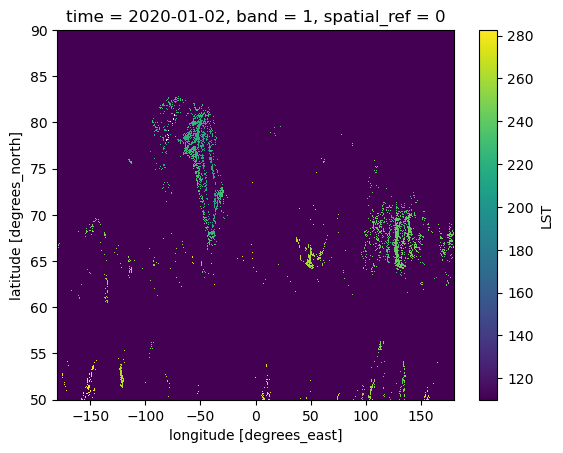

In [18]:
lst_2020['LST'].isel(time=1).plot();

In [19]:
# load the time series somewhere ?
results = {}

for year in range(2008, 2021):

    ds = globals()[f"lst_{year}"]   # load lst_1981, lst_1982, ...

    clean_LST = ds['LST'].where(ds['LST'] > 110, np.nan)
    monthly_mean = (
        clean_LST
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[year] = monthly_mean

combined = xr.concat([results[y] for y in range(2008, 2021)], dim="time")

In [20]:
combined

<xarray.DataArray 'LST' (lat: 800, lon: 7200, time: 156)> Size: 7GB
dask.array<concatenate, shape=(800, 7200, 156), dtype=float64, chunksize=(800, 7200, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01

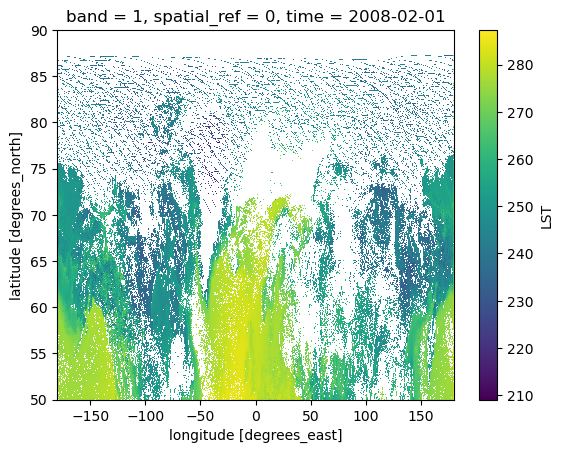

In [21]:
combined.isel(time=1).plot();

In [22]:
water_mask = rioxarray.open_rasterio('/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif')
water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))

water_mask_crop = water_mask.sel(lat=slice(50,90))
water_mask_true = combined.isel(time=0).copy(data=np.array(np.squeeze(water_mask_crop)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)

In [23]:
# compute trends
winter = combined.sel(time=combined.time.dt.month.isin([1,2, 12]))

In [24]:
winter['time']= winter['time'] + np.timedelta64(10000000000000000, 'ns')

In [25]:
winter_data = winter.groupby('time.year').mean()

In [26]:
winter_masked = winter_data * ls_mask

In [27]:
winter_masked = winter_masked.chunk({'year':-1, 'lon':1000, 'lat':100})

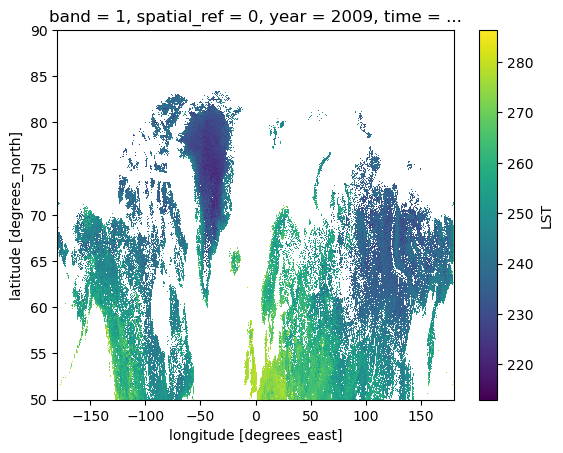

In [28]:
winter_masked.isel(year=1).plot();

In [29]:
def mk_test_p(y):
    if np.count_nonzero(np.isnan(y)) > 9:
        #print('catched_error')
        return np.nan
    #results = mk.original_test(y).slope
    p_vals = mk.original_test(y).p
    return p_vals

def mann_kendall_p(y, dim):
    return xr.apply_ufunc(
        mk_test_p,
        y,
        input_core_dims=[[dim]],
        dask ='parallelized',
        vectorize=True,
        output_dtypes=[float],)

In [30]:
with ProgressBar():
    p_val_winter = mann_kendall_p(winter_masked, dim="year").compute()
    # mask out oceans
p_val_winter_masked = p_val_winter*ls_mask
ds_p_val = p_val_winter_masked.to_dataset(name='p_val')
ds_p_val.to_netcdf('winter_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 38m 9ss


In [31]:
# compute trends
spring = combined.sel(time=combined.time.dt.month.isin([3,4, 5]))
spring_data = spring.groupby('time.year').mean()
spring_data = spring_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [32]:
with ProgressBar():
    p_val_spring = mann_kendall_p(spring_data, dim="year").compute()
    # mask out oceans
p_val_spring_masked = p_val_spring*ls_mask
ds_p_val_spring = p_val_spring_masked.to_dataset(name='p_val')
ds_p_val_spring.to_netcdf('spring_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 94m 27s


In [33]:
# compute trends
summer = combined.sel(time=combined.time.dt.month.isin([6,7, 8]))
summer_data = summer.groupby('time.year').mean()
summer_data = summer_data.chunk({'year':-1, 'lon':1000, 'lat':100})


In [34]:
with ProgressBar():
    p_val_summer = mann_kendall_p(summer_data, dim="year").compute()
    # mask out oceans
p_val_summer_masked = p_val_summer*ls_mask
ds_p_val_summer = p_val_summer_masked.to_dataset(name='p_val')
ds_p_val_summer.to_netcdf('summer_p_val_DAY.nc', format='NETCDF4')

[########################################] | 100% Completed | 85m 27s


In [35]:
# compute trends
fall = combined.sel(time=combined.time.dt.month.isin([9,10, 11]))
fall_data = fall.groupby('time.year').mean()
fall_data = fall_data.chunk({'year':-1, 'lon':1000, 'lat':100})


In [37]:
with ProgressBar():
    p_val_fall = mann_kendall_p(fall_data, dim="year").compute()
    # mask out oceans
p_val_fall_masked = p_val_fall*ls_mask
ds_p_val_fall = p_val_fall_masked.to_dataset(name='p_val')
ds_p_val_fall.to_netcdf('fall_p_val_DAY.nc', format='NETCDF4')

[                                        ] | 0% Completed | 35.55 sms

IOStream.flush timed out


[########################################] | 100% Completed | 75m 53s
